## Chapter 2

| **Term**                      | **Definition**                                                                                              |
|-------------------------------|-------------------------------------------------------------------------------------------------------------|
| **Distribution**              | The set of values in a dataset and how frequently each value appears.                                       |
| **Frequency table**           | A mapping from values to their frequencies.                                                                 |
| **Frequency**                 | The number of times a value appears in a sample.                                                            |
| **Skewed**                    | A distribution that is asymmetrical, with extreme values extending farther in one direction than the other. |
| **Mode**                      | The most frequent value in a sample (or one of the most frequent values).                                   |
| **Uniform distribution**      | A distribution in which all values have the same frequency.                                                 |
| **Outlier**                   | An extreme value in a distribution.                                                                         |
| **Standardized**              | A statistic expressed in a form that allows comparison across different datasets or domains.                |
| **Pooled standard deviation** | A statistic that combines data from two or more groups to calculate a common standard deviation.            |
| **Cohen’s effect size**       | A standardized statistic that quantifies the difference between the means of two groups.                    |
| **Practically significant**   | An effect that is large enough to matter in real-world or practical terms.                                  |


### Distribution

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from empiricaldist import FreqTab
import sys
sys.path.insert(0, '../nb')
from thinkstats import decorate

## 2.1. Frequency Tables

In [7]:
t = [1.0, 2.0, 2.0, 3.0, 5.0]

In [8]:
ftab = FreqTab.from_seq(t)
ftab

,freqs
1.0,1
2.0,2
3.0,1
5.0,1


A FreqTab object is a kind of Pandas Series that contains values and their frequencies

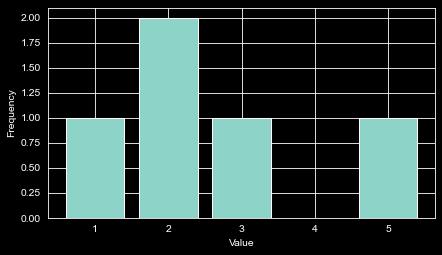

In [9]:
ftab.bar()
decorate(xlabel="Value", ylabel="Frequency")

In [10]:
ftab[2.0]

np.int64(2)

A FreqTab object has an attribute called qs that returns an array of values – qs stands for quantities, although technically not all values are quantities.

In [11]:
ftab.qs

array([1., 2., 3., 5.])

FreqTab also has an attribute called fs that returns an array of frequencies.

In [12]:
ftab.fs

array([1, 2, 1, 1])

FreqTab provides an items method we can use to loop through quantity-frequency pairs:

In [13]:
for x, freq in ftab.items():
    print(x, freq)

1.0 1
2.0 2
3.0 1
5.0 1


### 2.2. NSFG Distributions

In [14]:
from nsfg import read_fem_preg

preg = read_fem_preg('../data/2002FemPreg.dct', '../data/2002FemPreg.dat.gz')

C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


For the examples in this chapter, we’ll focus on pregnancies that ended in live birth.

In [15]:
live = preg.query("outcome == 1")

In [16]:
ftab_lb = FreqTab.from_seq(live["birthwgt_lb"], name="birthwgt_lb")

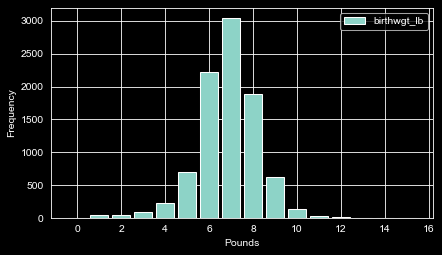

In [17]:
ftab_lb.bar()
decorate(xlabel="Pounds", ylabel="Frequency")

 The other notable feature of the distribution is the mode, which is the most common value. To find the mode, we can use the method idxmax, which finds the quantity associated with the highest frequency.

In [18]:
ftab_lb.idxmax()

np.float64(7.0)

In [19]:
ftab_lb.mode()

np.float64(7.0)

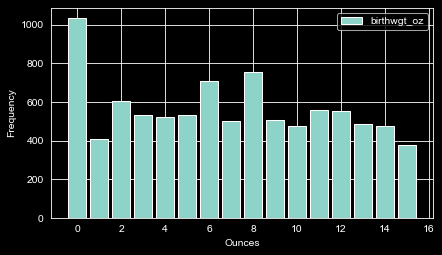

In [20]:
ftab_oz = FreqTab.from_seq(live["birthwgt_oz"], name="birthwgt_oz")
ftab_oz.bar()
decorate(xlabel="Ounces", ylabel="Frequency")

In [21]:
ftab_age = FreqTab.from_seq(live["agepreg"], name="agepreg")

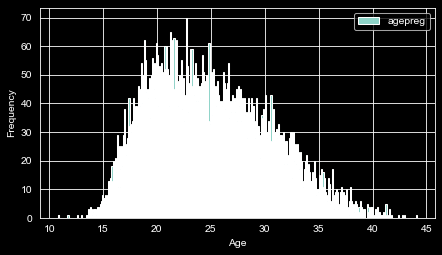

In [22]:
ftab_age.bar(width=0.1)
decorate(xlabel="Age", ylabel="Frequency")

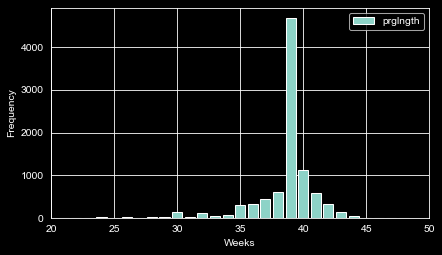

In [23]:
ftab_length = FreqTab.from_seq(live["prglngth"], name="prglngth")
ftab_length.bar()
decorate(xlabel="Weeks", ylabel="Frequency", xlim=[20, 50])

### 2.3. Outliers

In [24]:
def smallest(ftab, n=10):
    return ftab[:n]

In [25]:
smallest(ftab_length)

prglngth
0     1
4     1
9     1
13    1
17    2
18    1
19    1
20    1
21    2
22    7
Name: prglngth, dtype: int64

The following function selects the largest values from a FreqTab object.

In [26]:
def largest(ftab, n=10):
    return ftab[-n:]

In [27]:
largest(ftab_length)

prglngth
40    1116
41     587
42     328
43     148
44      46
45      10
46       1
47       1
48       7
50       2
Name: prglngth, dtype: int64

### 2.4. First Babies

In [28]:
firsts = live.query("birthord == 1")
others = live.query("birthord != 1")

In [29]:
ftab_first = FreqTab.from_seq(firsts["prglngth"], name="firsts")
ftab_other = FreqTab.from_seq(others["prglngth"], name="others")

In [30]:
def two_bar_plots(ftab1, ftab2, width=0.45):
    ftab1.bar(align="edge", width=-width)
    ftab2.bar(align="edge", width=width, alpha=0.5)

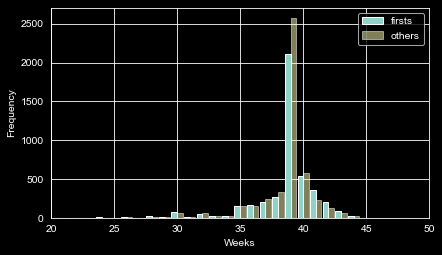

In [31]:
two_bar_plots(ftab_first, ftab_other)
decorate(xlabel="Weeks", ylabel="Frequency", xlim=[20, 50])

In [32]:
firsts["prglngth"].count(), others["prglngth"].count()

(np.int64(4413), np.int64(4735))

In [33]:
first_mean = firsts["prglngth"].mean()
other_mean = others["prglngth"].mean()
first_mean, other_mean

(np.float64(38.60095173351461), np.float64(38.52291446673706))

In [34]:
diff = first_mean - other_mean
diff, diff * 7 * 24

(np.float64(0.07803726677754952), np.float64(13.11026081862832))

There are several possible causes of this apparent difference:

There might be an actual difference in average pregnancy length between first babies and others.

The apparent difference we see in this dataset might be the result of bias in the sampling process – that is, the selection of survey respondents.

The apparent difference might be the result of measurement error – for example, the self-reported pregnancy lengths might be more accurate for first babies or others.

The apparent difference might be the result of random variation in the sampling process.

### 2.5. Effect Size

In [35]:
diff / live["prglngth"].mean() * 100

np.float64(0.20237586646738304)

0.2% longer on average

Another option is to report a standardized effect size, which is a statistic intended to quantify the size of an effect in a way that is comparable between different quantities and different groups.

In [36]:
diff / live["prglngth"].std()

np.float64(0.028877623375210403)

We used both groups to compute the standard deviation. If the groups are substantially different, the standard deviation when we put them together is larger than in either group, which might make the effect size seem small.

An alternative is to use the standard deviation of just one group, but it’s not clear which. So we could take the average of the two standard deviations, but if the groups are different sizes, that would give too much weight to one group and not enough to the other.

A common solution is to use pooled standard deviation, which is the square root of pooled variance, which is the weighted sum of the variances in the groups. To compute it, we’ll start with the variances.

In [37]:
group1, group2 = firsts["prglngth"], others["prglngth"]

In [38]:
v1, v2 = group1.var(), group2.var()

In [39]:
n1, n2 = group1.count(), group2.count()
pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)

In [40]:
np.sqrt(pooled_var)

np.float64(2.7022108144953862)

The pooled standard deviation is between the standard deviations of the groups.

In [41]:
firsts["prglngth"].std(), others["prglngth"].std()

(np.float64(2.7919014146687204), np.float64(2.6158523504392375))

A standardized effect size that uses pooled standard deviation is called Cohen’s effect size. Here’s a function that computes it.

In [42]:
def cohen_effect_size(group1, group2):
    diff = group1.mean() - group2.mean()

    v1, v2 = group1.var(), group2.var()
    n1, n2 = group1.count(), group2.count()
    pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)

    return diff / np.sqrt(pooled_var)

In [43]:
cohen_effect_size(firsts["prglngth"], others["prglngth"])

np.float64(0.028879044654449834)

### 2.6. Reporting results

How you report results also depends on your goals. If you are trying to demonstrate the importance of an effect, you might choose summary statistics that emphasize differences. If you are trying to reassure a patient, you might choose statistics that put the differences in context.

### 2.8. Exercises

In [45]:
from nsfg import read_fem_resp

resp = read_fem_resp('../data/2002FemResp.dct', '../data/2002FemResp.dat.gz')
resp.shape

C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["agemarry"] = (resp.cmmarrhx - resp.cmbirth) / 12.0
C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["age"] = (resp.cmintvw - resp.cmbirth) / 12.0
C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

(7643, 3092)

#### 2.8.1. Exercise 2.1, Make a FreqTab object to represent the distribution of this variable and plot it as a bar chart.

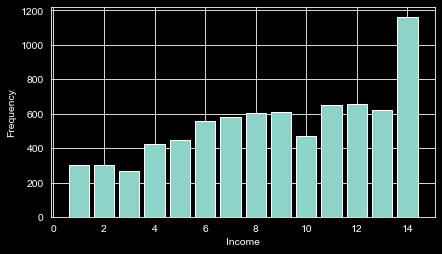

In [48]:
ftab_incr = FreqTab.from_seq(resp['totincr'])
ftab_incr.bar()
decorate(xlabel="Income", ylabel="Frequency")

### 2.8.2. Exercise 2.2, Make a frequency table of the parity column, which records the number of children each respondent has borne. How would you describe the shape of this distribution?

Use the largest function to find the largest values of parity. Are there any values you think are errors?